# Turtle / Donchian Breakout with a De-Time Trend Filter

Classical Turtle-style breakout systems enter when price breaks above a prior high and exit on a lower-channel break. De-Time adds a trend confirmation layer so the breakout must agree with the decomposed trend.

**Default decomposition:** `ROBUST_STL` with a 63-trading-day period, computed walk-forward where signals are backtested.


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from examples.quant_trading.data import fetch_yahoo_prices, fetch_yahoo_ohlcv, data_audit_report, DEFAULT_UNIVERSES
from examples.quant_trading.features import decompose_one_series, walkforward_decompose, build_feature_table
from examples.quant_trading.signals import (
    trend_pullback_signals,
    residual_mean_reversion_signals,
    turtle_donchian_signals,
    pair_trading_weights,
    cross_sectional_rotation_weights,
    residual_stress_filter,
)
from examples.quant_trading.backtest import backtest_weights, backtest_long_short_signals, summarize_returns

DATA_CACHE = Path("examples/quant_trading/data/cache")
QUANT_METHOD = "ROBUST_STL"
QUANT_PERIOD = 63


In [2]:
prices = fetch_yahoo_prices(["SPY", "QQQ", "IWM", "DIA"], start="2016-01-01", cache_dir=DATA_CACHE)
features = walkforward_decompose(prices, method=QUANT_METHOD, period=QUANT_PERIOD, train_window=252, step=21)
raw_entries, raw_exits = turtle_donchian_signals(prices, entry_window=55, exit_window=20, use_trend_filter=False)
entries, exits = turtle_donchian_signals(prices, features, entry_window=55, exit_window=20, use_trend_filter=True)
result = backtest_long_short_signals(prices, entries, exits, fee_bps=1.0, slippage_bps=2.0)
result.stats_frame()

,value
total_return,1.049485
cagr,0.071684
volatility,0.096409
sharpe,0.766505
max_drawdown,-0.163652
calmar,0.438026
hit_rate,0.303982
average_turnover,0.046069
average_gross_exposure,0.541730
fee_bps,1.000000


In [3]:
pd.DataFrame({
    "raw_breakouts": raw_entries.sum(),
    "accepted_by_trend_filter": entries.sum(),
    "blocked_by_trend_filter": (raw_entries & ~entries).sum(),
    "exits": exits.sum(),
})

,raw_breakouts,accepted_by_trend_filter,blocked_by_trend_filter,exits
SPY,512,394,118,180
QQQ,489,369,120,185
IWM,287,171,116,212
DIA,418,309,109,180


## Decomposition rule map

Donchian supplies the price breakout. De-Time does not create the breakout; it decides whether the breakout agrees with the decomposed trend at that timestamp.

In [4]:
pd.DataFrame([
    {"input": "55-day Donchian high", "source": "price", "rule_role": "raw breakout candidate"},
    {"input": "trend_slope > 0", "source": "De-Time trend", "rule_role": "accept or block the breakout"},
    {"input": "20-day Donchian low", "source": "price", "rule_role": "exit rule"},
    {"input": "residual_abs_z", "source": "De-Time residual", "rule_role": "post-run diagnostic for noisy breakouts"},
])

,input,source,rule_role
0,55-day Donchian high,price,raw breakout candidate
1,trend_slope > 0,De-Time trend,accept or block the breakout
2,20-day Donchian low,price,exit rule
3,residual_abs_z,De-Time residual,post-run diagnostic for noisy breakouts


## Visualization: Donchian breakout channels

The SPY channel plot shows how the De-Time trend filter gates classic Donchian entries and exits.

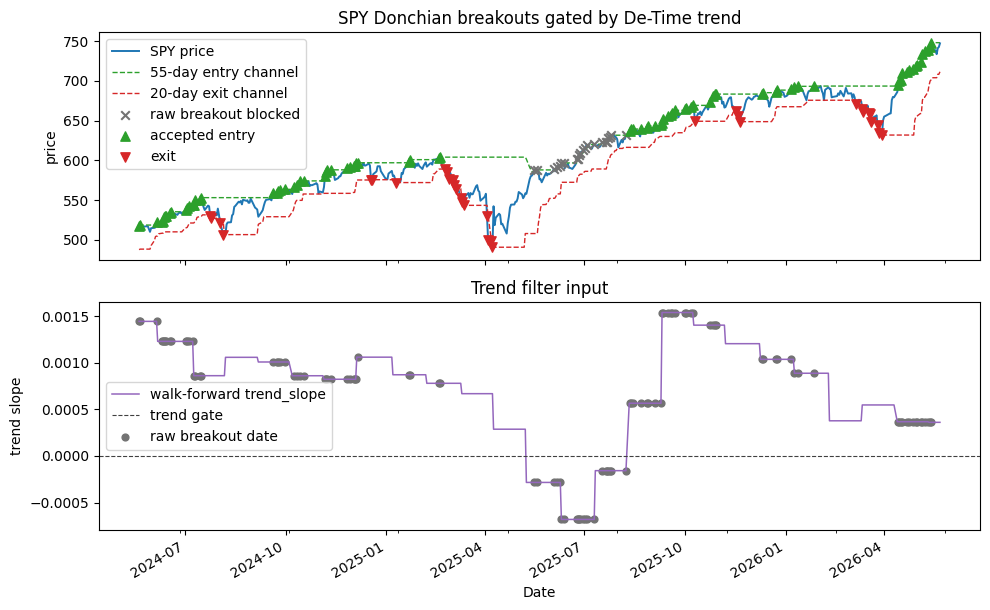

In [5]:
asset = "SPY"
window = prices.index[-504:]
price_line = prices.loc[window, asset]
upper = prices[asset].rolling(55, min_periods=27).max().shift(1).reindex(window)
lower = prices[asset].rolling(20, min_periods=10).min().shift(1).reindex(window)
raw_points = raw_entries.loc[window, asset].fillna(False).astype(bool)
entry_points = entries.loc[window, asset].fillna(False).astype(bool)
exit_points = exits.loc[window, asset].fillna(False).astype(bool)
blocked_points = raw_points & ~entry_points
trend_slope = features["trend_slope"][asset].reindex(window)

fig, axes = plt.subplots(2, 1, figsize=(10, 6.2), sharex=True)
price_line.plot(ax=axes[0], color="tab:blue", linewidth=1.4, label="SPY price")
upper.plot(ax=axes[0], color="tab:green", linestyle="--", linewidth=1.0, label="55-day entry channel")
lower.plot(ax=axes[0], color="tab:red", linestyle="--", linewidth=1.0, label="20-day exit channel")
axes[0].scatter(blocked_points[blocked_points].index, price_line.loc[blocked_points[blocked_points].index], marker="x", color="0.45", s=38, zorder=3, label="raw breakout blocked")
axes[0].scatter(entry_points[entry_points].index, price_line.loc[entry_points[entry_points].index], marker="^", color="tab:green", s=45, zorder=4, label="accepted entry")
axes[0].scatter(exit_points[exit_points].index, price_line.loc[exit_points[exit_points].index], marker="v", color="tab:red", s=45, zorder=4, label="exit")
axes[0].set_title("SPY Donchian breakouts gated by De-Time trend")
axes[0].set_ylabel("price")
axes[0].legend(loc="best")

trend_slope.plot(ax=axes[1], color="tab:purple", linewidth=1.1, label="walk-forward trend_slope")
axes[1].axhline(0.0, color="0.25", linestyle="--", linewidth=0.8, label="trend gate")
axes[1].scatter(raw_points[raw_points].index, trend_slope.loc[raw_points[raw_points].index], marker="o", color="0.45", s=24, label="raw breakout date")
axes[1].set_title("Trend filter input")
axes[1].set_ylabel("trend slope")
axes[1].legend(loc="best")
plt.tight_layout()
plt.show()

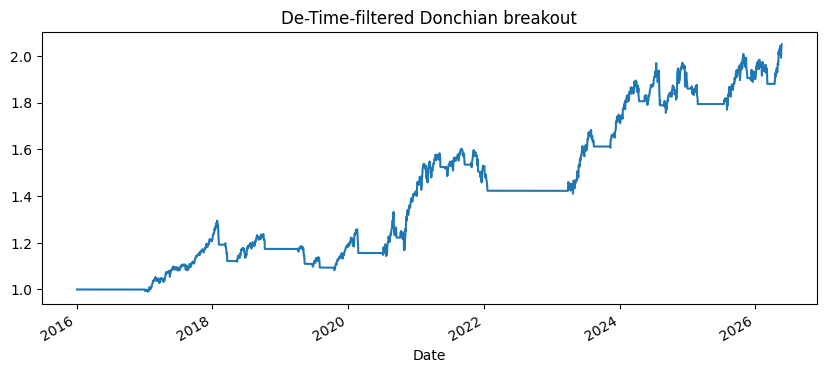

In [6]:
result.equity.plot(figsize=(10, 4), title="De-Time-filtered Donchian breakout")
plt.show()